In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('alex_paper.mplstyle')
import compute_S_rate
import auxiliary_functions
from scipy import sparse

Could not load cython functions. Some functionality might be broken.
Could not load sparse_dot_mkl. Will use scipy.sparse for matrix products.


In [2]:
#Closed Formula Heat Diffussion Complete Graph
H_Heat = lambda t, n: np.log(n) - (n-1)/n*np.exp(-(n*t))*np.log((1+(n-1)*np.exp(-(n*t))) / (1-np.exp(-(n*t)))) - (n-1)/n * np.log(1-np.exp(-(n*t))) - 1/n*np.log(1+ (n-1)*np.exp((-n*t)))

In [3]:
def heat_kernel_path_graph(N: int, t: float) -> np.ndarray:
    """
    Return the heat‑diffusion transition matrix e^{−tL} for the simple path
    graph P_N (vertices 0,…,N−1 with edges i–(i+1)).

    Parameters
    ----------
    N : int
        Number of vertices of the path graph.
    t : float
        Diffusion time (non‑negative).

    Returns
    -------
    T : ndarray, shape (N, N)
        Row‑stochastic transition matrix whose (i, j) entry gives
        the probability of being at vertex j at time t when starting
        from vertex i.
    """
    # Eigenvalues λ_k = 2(1 − cos(π k / N)),  k = 0,…,N−1
    k = np.arange(N)
    lambdas = 2.0 * (1.0 - np.cos(np.pi * k / N))

    # Eigenvectors:
    #   – k = 0: constant vector (normalised)
    #   – k ≥ 1: DST‑II cosine modes with a half‑shift (j + 0.5)
    j = np.arange(N).reshape(-1, 1)          # column of vertex indices
    U0 = np.ones((N, 1)) / np.sqrt(N)        # constant eigenvector
    k1 = np.arange(1, N).reshape(1, -1)      # row of mode indices
    U_rest = np.sqrt(2.0 / N) * np.cos(np.pi * k1 * (j + 0.5) / N)

    U = np.hstack((U0, U_rest))              # full eigenvector matrix (orthonormal)

    # Heat kernel: U · diag(e^{−λ_k t}) · Uᵀ
    T = (U * np.exp(-lambdas * t)) @ U.T

    # Numerical clean‑up: set tiny negative round‑off to zero and renormalise rows
    T = np.clip(T, 0.0, None)
    T /= T.sum(axis=1, keepdims=True)

    return sparse.csr_matrix(T)

In [5]:
def heat_circulant_matrix(n, S, t):
    """
    Heat-transition matrix  e^{-tL}  of the undirected circulant graph C_n(S).

    Parameters
    ----------
    n : int
        Number of vertices (labelled 0 … n-1).
    S : iterable of int
        Positive step sizes (1 ≤ s ≤ ⌊n/2⌋).  Each s adds the edges
        {i, i±s mod n}.  If n is even and n/2∈S, that step contributes
        only ONE neighbour per vertex.
    t : float
        Diffusion (heat) time  t ≥ 0.

    Returns
    -------
    H : ndarray, shape (n, n), dtype=float
        The row-stochastic heat matrix  H = exp(−t L).
    """
    S = {int(s) % n for s in S if s % n != 0}      # sanitise
    # ------------------------------------------------------------
    # 1. first row of the adjacency matrix (length-n circulant vector)
    c = np.zeros(n, dtype=float)
    for s in S:
        c[s] = 1
        opp = (-s) % n
        if opp != s:               # skip the duplicate when s = n/2
            c[opp] = 1
    # degree of every vertex
    d = int(c.sum())
    # ------------------------------------------------------------
    # 2. spectrum of the adjacency matrix via FFT
    λ = np.fft.fft(c)              # length-n array of eigen-values
    # 3. eigen-values of −L = −(dI − A)
    exp_eigs = np.exp(-t * (d - λ))
    # 4. inverse FFT → first row of heat kernel
    h = np.fft.ifft(exp_eigs).real   # numerical imag parts ≈ 0
    # ------------------------------------------------------------
    # 5. build full circulant heat matrix from its first row
    H = np.vstack([np.roll(h, i) for i in range(n)])
    return sparse.csr_matrix(H)

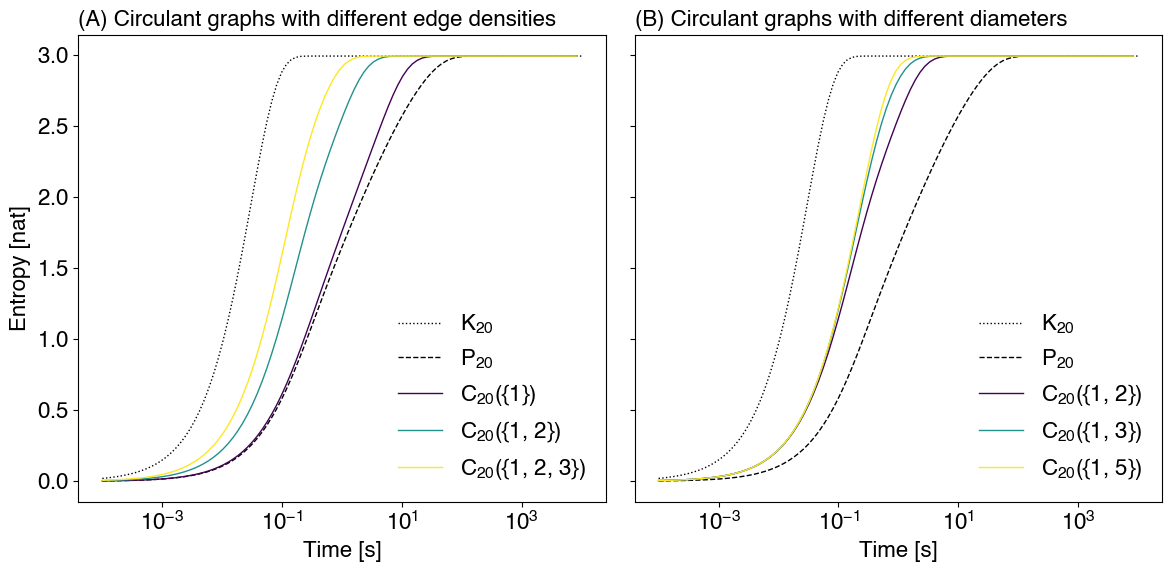

In [ ]:
# Start creating the figure
fig = plt.figure(figsize=(12, 6))  # Wider figure for all plots in one row
gs = fig.add_gridspec(1, 2)  # Grid: 1 row, 4 columns

N = 20
lambda_value = 1.0
time = np.logspace(-4, 4, 100)

#Complete graph
formula_entropy = [H_Heat(t, N) for t in time]

#Path Graph
Transitions = [heat_kernel_path_graph(N, t) for t in time]
p0 = p0 = 1/N*np.ones(N)
formula_entropy_2 = compute_S_rate.compute_conditional_entropy(list_T=Transitions, lamda=lambda_value, force_csr=True, time_domain=list(np.arange(0, len(time) - 1)), p0=p0)


# Column 1: Plot A
ax_a = fig.add_subplot(gs[0, 0])

Step_sets = [{1}, {1, 2}, {1, 2, 3}]
colours = ['k']
colours += auxiliary_functions.generate_viridis_colors(len(Step_sets))

#Plot complete graph
ax_a.plot(time, formula_entropy, label=r"$K_{20}$", color=colours[0], linestyle=':')
#Plot path Graph
ax_a.plot(time[:-1], formula_entropy_2[list(formula_entropy_2.keys())[0]][1:], label=r"$P_{20}$", color=colours[0], linestyle='--')

# Loop over different circulant graphs
for i, s in enumerate(Step_sets):
    #Circulant Graph
    # Compute approximate entropy
    Transitions = [heat_circulant_matrix(N, s, t) for t in time]
    p0 = p0 = 1/N*np.ones(N)
    formula_entropy_circulant = compute_S_rate.compute_conditional_entropy(list_T=Transitions, lamda=lambda_value, force_csr=True, time_domain=list(np.arange(0, len(time) - 1)), p0=p0)
    ax_a.plot(time[:-1], formula_entropy_circulant[list(formula_entropy_circulant.keys())[0]][1:], label=fr"$C_{{{N}}}$({s})", color=colours[i+1])

ax_a.set_xscale('log')
ax_a.set_xlabel('Time [s]')
ax_a.set_ylabel('Entropy [nat]')
ax_a.set_title('(A) Circulant graphs with different edge densities', loc='left')
ax_a.legend()

# Column 2: Plot B
ax_b = fig.add_subplot(gs[0, 1], sharey=ax_a)
plt.setp(ax_b.get_yticklabels(), visible=False)

Step_sets = [{1, 2}, {1, 3}, {1,5}]
colours = ['k']
colours += auxiliary_functions.generate_viridis_colors(len(Step_sets))

#Plot complete graph
ax_b.plot(time, formula_entropy, label=r"$K_{20}$", color=colours[0], linestyle=':')
#Plot path Graph
ax_b.plot(time[:-1], formula_entropy_2[list(formula_entropy_2.keys())[0]][1:], label=r"$P_{20}$", color=colours[0], linestyle='--')

# Loop over different circulant graphs
for i, s in enumerate(Step_sets):
    #Circulant Graph
    # Compute approximate entropy
    Transitions = [heat_circulant_matrix(N, s, t) for t in time]
    p0 = p0 = 1/N*np.ones(N)
    formula_entropy_circulant = compute_S_rate.compute_conditional_entropy(list_T=Transitions, lamda=lambda_value, force_csr=True, time_domain=list(np.arange(0, len(time) - 1)), p0=p0)
    ax_b.plot(time[:-1], formula_entropy_circulant[list(formula_entropy_circulant.keys())[0]][1:], label=fr"$C_{{{N}}}$({s})", color=colours[i+1])

ax_b.set_xscale('log')
ax_b.set_xlabel('Time [s]')
ax_b.set_title("(B) Circulant graphs with different diameters", loc='left')
ax_b.legend(loc='lower right')


# Adjust layout and display
plt.tight_layout()
#plt.savefig('/Users/samuelkoovely/Desktop/fig_entropy/circulant_curves.pdf', format='pdf')
plt.show()